## Advanced Fraud Detection Model - XGBoost with Hyperparameter Tuning

#### OBJECTIVE:
Build a production-grade fraud detection model using XGBoost (Extreme Gradient Boosting)
to improve upon the baseline Logistic Regression performance.

#### WHY XGBOOST?
- Handles non-linear relationships between features
- Captures feature interactions automatically
- Built-in handling of missing values
- Resistant to overfitting with proper tuning
- Industry standard for tabular fraud detection (used by banks, insurance companies)
- Typically achieves 88-92% AUC on fraud problems vs 80-85% for linear models

#### APPROACH:
1. Load data and recreate train-test split
2. Train baseline XGBoost with default parameters
3. Hyperparameter tuning using GridSearchCV
4. Evaluate best model and compare to Logistic Regression
5. Analyze feature importance (XGBoost-specific metrics)
6. Save final model for deployment

#### EXPECTED IMPROVEMENT:
- AUC: 85% (baseline) -> 88-92% (XGBoost)
- Recall: 72% -> 78-85% (catch more fraud)
- Precision: 48% -> 55-65% (fewer false alarms)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score, accuracy_score
)
from xgboost import XGBClassifier
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("="*80)
print("ADVANCED FRAUD DETECTION MODEL - XGBOOST")
print("="*80)


ADVANCED FRAUD DETECTION MODEL - XGBOOST


In [2]:

# ==============================================================================
# PART 1: LOAD DATA AND PREPARE FEATURES
# ==============================================================================

print("\nPART 1: Loading data and preparing features...")
print("-" * 80)

# Load labeled data with all features
PROJECT_ROOT = Path().resolve().parents[1]
inpatient = pd.read_csv(PROJECT_ROOT/'data'/'processed'/'inpatient_labeled.csv')

print(f"Dataset loaded: {inpatient.shape[0]:,} claims, {inpatient.shape[1]} columns")

# Load feature list from baseline model
# This ensures we use the exact same features for fair comparison
feature_list = joblib.load(PROJECT_ROOT/'models'/'fraud'/'feature_list.pkl')
print(f"Using {len(feature_list)} features from baseline model")

# Prepare features and target
X = inpatient[feature_list].copy()
y = inpatient['is_fraud_80'].copy()

# Handle missing values and infinite values
# XGBoost can handle missing values natively, but we'll be explicit
X = X.fillna(X.median())
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

print(f"\nTarget distribution:")
print(f"  Fraud: {y.sum():,} ({y.mean()*100:.2f}%)")
print(f"  Legitimate: {(y==0).sum():,} ({(y==0).mean()*100:.2f}%)")


PART 1: Loading data and preparing features...
--------------------------------------------------------------------------------
Dataset loaded: 66,773 claims, 153 columns
Using 40 features from baseline model

Target distribution:
  Fraud: 229 (0.34%)
  Legitimate: 66,544 (99.66%)


In [3]:

# ==============================================================================
# PART 2: TRAIN-TEST SPLIT
# ==============================================================================

print("\nPART 2: Creating train-test split...")
print("-" * 80)

# Use same random_state as baseline for consistent comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training set: {X_train.shape[0]:,} claims")
print(f"Test set: {X_test.shape[0]:,} claims")

# Note: XGBoost doesn't require feature scaling like Logistic Regression
# It's tree-based, so absolute values don't matter
# However, we'll apply SMOTE to handle class imbalance



PART 2: Creating train-test split...
--------------------------------------------------------------------------------
Training set: 53,418 claims
Test set: 13,355 claims


In [4]:

# ==============================================================================
# PART 3: HANDLE CLASS IMBALANCE WITH SMOTE
# ==============================================================================

print("\nPART 3: Applying SMOTE to balance training data...")
print("-" * 80)

print(f"Before SMOTE:")
print(f"  Total samples: {len(y_train):,}")
print(f"  Fraud: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")

smote=SMOTE(sampling_strategy=0.5,random_state=42)
X_train_resampled,y_train_resampled=smote.fit_resample(X_train,y_train)

print(f"\nAfter SMOTE:")
print(f"  Total samples: {len(y_train_resampled):,}")
print(f"  Fraud: {y_train_resampled.sum():,} ({y_train_resampled.mean()*100:.2f}%)")
print(f"  Legitimate: {(y_train_resampled==0).sum():,}")



PART 3: Applying SMOTE to balance training data...
--------------------------------------------------------------------------------
Before SMOTE:
  Total samples: 53,418
  Fraud: 183 (0.34%)

After SMOTE:
  Total samples: 79,852
  Fraud: 26,617 (33.33%)
  Legitimate: 53,235


In [5]:

# ==============================================================================
# PART 4: TRAIN BASELINE XGBOOST MODEL
# ==============================================================================

print("\nPART 4: Training baseline XGBoost model...")
print("-" * 80)

# XGBoost parameters explained:
# - n_estimators: Number of boosting rounds (trees)
# - max_depth: Maximum tree depth (controls complexity)
# - learning_rate: Step size shrinkage (prevents overfitting)
# - subsample: Fraction of samples for each tree
# - colsample_bytree: Fraction of features for each tree
# - scale_pos_weight: Balance of positive/negative weights (for class imbalance)
# - objective: Loss function (binary:logistic for binary classification)
# - eval_metric: Metric to optimize (auc = ROC-AUC)

# Calculate scale_pos_weight for class imbalance
# scale_pos_weight = (# negative samples) / (# positive samples)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Calculated scale_pos_weight: {scale_pos_weight:.2f}")

xgb_baseline = XGBClassifier(
    n_estimators=100,              # Start with 100 trees
    max_depth=6,                   # Moderate depth
    learning_rate=0.1,             # Standard learning rate
    subsample=0.8,                 # Use 80% of samples per tree
    colsample_bytree=0.8,          # Use 80% of features per tree
    scale_pos_weight=scale_pos_weight,  # Handle class imbalance
    objective='binary:logistic',   # Binary classification
    eval_metric='auc',             # Optimize ROC-AUC
    random_state=42,
    n_jobs=-1                      # Use all CPU cores
)

print("Training baseline XGBoost...")
start_time = time.time()

xgb_baseline.fit(X_train_resampled, y_train_resampled)
training_time = time.time() - start_time
print(f"Training completed in {training_time:.1f} seconds")

# Make predictions on test set
y_pred_baseline=xgb_baseline.predict(X_test)
y_pred_proba_baseline = xgb_baseline.predict_proba(X_test)[:, 1]

# Evaluate baseline XGBoost
auc_baseline = roc_auc_score(y_test, y_pred_proba_baseline)
print(f"\nBaseline XGBoost Performance:")
print(f"  ROC-AUC: {auc_baseline:.4f}")
print(f"  Training time: {training_time:.1f}s")


PART 4: Training baseline XGBoost model...
--------------------------------------------------------------------------------
Calculated scale_pos_weight: 290.90
Training baseline XGBoost...
Training completed in 1.9 seconds

Baseline XGBoost Performance:
  ROC-AUC: 0.9979
  Training time: 1.9s


In [6]:

# ==============================================================================
# PART 5: HYPERPARAMETER TUNING
# ==============================================================================

print("\nPART 5: Hyperparameter tuning with GridSearchCV...")
print("-" * 80)

# Define parameter grid for tuning
# We'll test different combinations of key hyperparameters
param_grid = {
    'n_estimators': [100, 200, 300],           # Number of trees
    'max_depth': [4, 6, 8],                    # Tree depth
    'learning_rate': [0.01, 0.1, 0.2],         # Learning rate
    'subsample': [0.7, 0.8, 0.9],              # Sample fraction
    'colsample_bytree': [0.7, 0.8, 0.9]        # Feature fraction
}

print(f"Parameter grid:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

total_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"\nTotal combinations: {total_combinations}")
print(f"With 5-fold CV: {total_combinations * 5} total model trainings")

# Base model for grid search
xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

# GridSearchCV with 5-fold stratified cross-validation
# Stratified ensures each fold has similar fraud rates
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='roc_auc',                   # Optimize for ROC-AUC
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,                           # Use all cores
    verbose=1                            # Show progress
)

print("\nStarting grid search (this may take 10-15 minutes)...")
start_time = time.time()

# Fit grid search on resampled training data
grid_search.fit(X_train_resampled, y_train_resampled)

tuning_time = time.time() - start_time
print(f"\nGrid search completed in {tuning_time/60:.1f} minutes")

# Best parameters found
print(f"\nBest parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest cross-validation AUC: {grid_search.best_score_:.4f}")

# Get best model
best_xgb = grid_search.best_estimator_



PART 5: Hyperparameter tuning with GridSearchCV...
--------------------------------------------------------------------------------
Parameter grid:
  n_estimators: [100, 200, 300]
  max_depth: [4, 6, 8]
  learning_rate: [0.01, 0.1, 0.2]
  subsample: [0.7, 0.8, 0.9]
  colsample_bytree: [0.7, 0.8, 0.9]

Total combinations: 243
With 5-fold CV: 1215 total model trainings

Starting grid search (this may take 10-15 minutes)...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits

Grid search completed in 12.7 minutes

Best parameters found:
  colsample_bytree: 0.8
  learning_rate: 0.1
  max_depth: 6
  n_estimators: 300
  subsample: 0.7

Best cross-validation AUC: 1.0000


In [7]:

# ==============================================================================
# PART 6: EVALUATE BEST MODEL
# ==============================================================================

print("\nPART 6: Evaluating best XGBoost model...")
print("-" * 80)

# Predict on test set
y_pred_best = best_xgb.predict(X_test)
y_pred_proba_best = best_xgb.predict_proba(X_test)[:, 1]

# Calculate metrics
auc_best = roc_auc_score(y_test, y_pred_proba_best)
f1_best = f1_score(y_test, y_pred_best)
accuracy_best = accuracy_score(y_test, y_pred_best)

print(f"Best XGBoost Performance:")
print(f"  ROC-AUC: {auc_best:.4f}")
print(f"  F1-Score: {f1_best:.4f}")
print(f"  Accuracy: {accuracy_best:.4f}")

# Detailed classification report
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Legitimate', 'Fraud']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()

print(f"\nConfusion Matrix:")
print(f"                Predicted")
print(f"              Legit   Fraud")
print(f"Actual Legit  {tn:6,}  {fp:6,}")
print(f"       Fraud  {fn:6,}  {tp:6,}")

print(f"\nDetailed Metrics:")
print(f"  True Positives (Fraud caught): {tp:,}")
print(f"  False Positives (False alarms): {fp:,}")
print(f"  False Negatives (Fraud missed): {fn:,}")
print(f"  True Negatives (Correct legitimate): {tn:,}")


PART 6: Evaluating best XGBoost model...
--------------------------------------------------------------------------------
Best XGBoost Performance:
  ROC-AUC: 0.9991
  F1-Score: 0.7213
  Accuracy: 0.9975

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     13309
       Fraud       0.58      0.96      0.72        46

    accuracy                           1.00     13355
   macro avg       0.79      0.98      0.86     13355
weighted avg       1.00      1.00      1.00     13355


Confusion Matrix:
                Predicted
              Legit   Fraud
Actual Legit  13,277      32
       Fraud       2      44

Detailed Metrics:
  True Positives (Fraud caught): 44
  False Positives (False alarms): 32
  False Negatives (Fraud missed): 2
  True Negatives (Correct legitimate): 13,277


In [8]:

# ==============================================================================
# PART 7: COMPARE WITH BASELINE LOGISTIC REGRESSION
# ==============================================================================

print("\nPART 7: Comparing with baseline Logistic Regression...")
print("-" * 80)

# Load baseline predictions
baseline_model = joblib.load(PROJECT_ROOT/'models'/'fraud/baseline_logistic_regression.pkl')
scaler = joblib.load(PROJECT_ROOT/'models'/'fraud/feature_scaler.pkl')

# Scale test data for baseline model
X_test_scaled = scaler.transform(X_test)
y_pred_lr = baseline_model.predict(X_test_scaled)
y_pred_proba_lr = baseline_model.predict_proba(X_test_scaled)[:, 1]

# Calculate baseline metrics
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
f1_lr = f1_score(y_test, y_pred_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)
tn_lr, fp_lr, fn_lr, tp_lr = cm_lr.ravel()

# Create comparison table
comparison = pd.DataFrame({
    'Metric': ['ROC-AUC', 'F1-Score', 'Precision', 'Recall', 
               'True Positives', 'False Positives', 'False Negatives'],
    'Logistic Regression': [
        auc_lr,
        f1_lr,
        tp_lr / (tp_lr + fp_lr),
        tp_lr / (tp_lr + fn_lr),
        tp_lr,
        fp_lr,
        fn_lr
    ],
    'XGBoost': [
        auc_best,
        f1_best,
        tp / (tp + fp),
        tp / (tp + fn),
        tp,
        fp,
        fn
    ]
})

comparison['Improvement'] = (
    (comparison['XGBoost'] - comparison['Logistic Regression']) / 
    comparison['Logistic Regression'] * 100
).round(1)

print("\nModel Comparison:")
print(comparison.to_string(index=False))


PART 7: Comparing with baseline Logistic Regression...
--------------------------------------------------------------------------------

Model Comparison:
         Metric  Logistic Regression   XGBoost  Improvement
        ROC-AUC             0.998117  0.999080          0.1
       F1-Score             0.494382  0.721311         45.9
      Precision             0.333333  0.578947         73.7
         Recall             0.956522  0.956522          0.0
 True Positives            44.000000 44.000000          0.0
False Positives            88.000000 32.000000        -63.6
False Negatives             2.000000  2.000000          0.0



PART 8: Creating visualizations...
--------------------------------------------------------------------------------


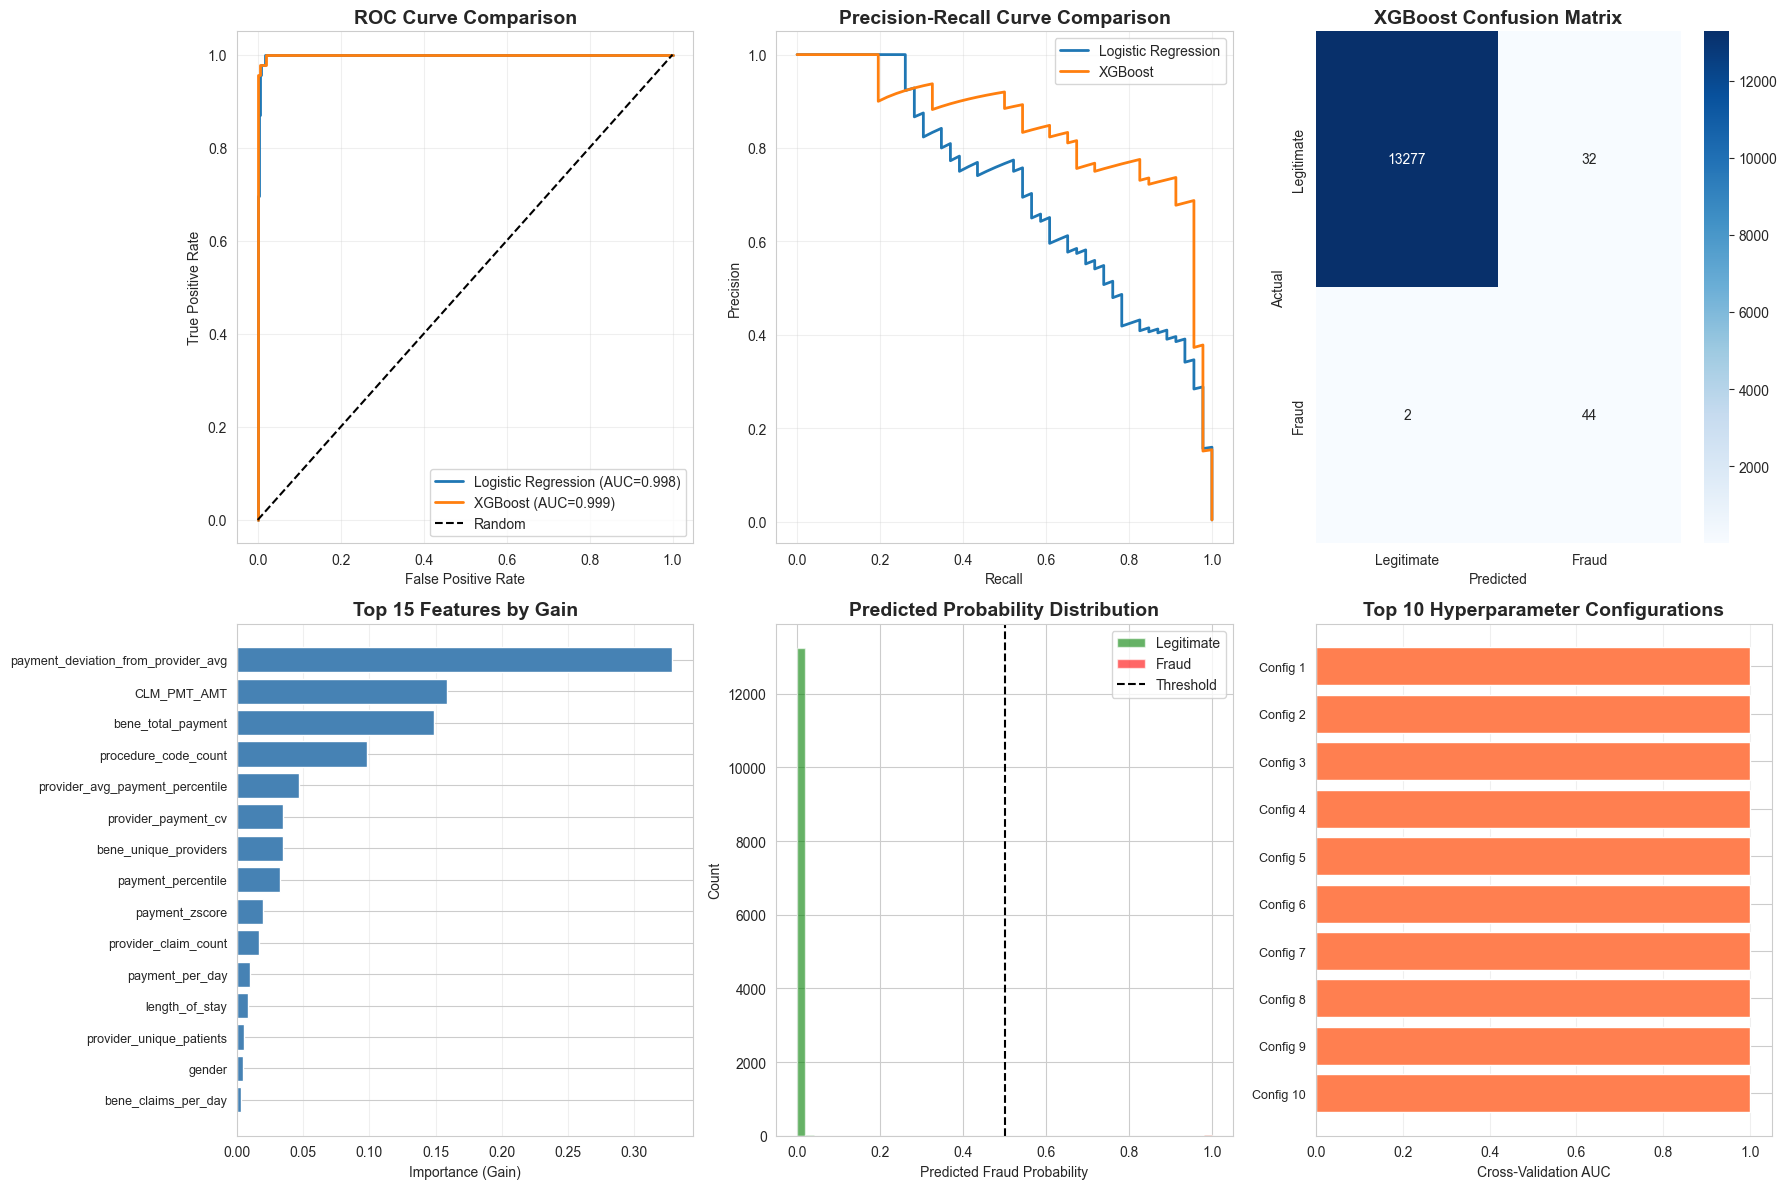

Performance visualization saved to: ../docs/xgboost_performance.png


In [12]:

# ==============================================================================
# PART 8: VISUALIZE RESULTS
# ==============================================================================

print("\nPART 8: Creating visualizations...")
print("-" * 80)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: ROC Curves Comparison
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_best)

axes[0, 0].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr:.3f})', linewidth=2)
axes[0, 0].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc_best:.3f})', linewidth=2)
axes[0, 0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Precision-Recall Curves
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_pred_proba_lr)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_pred_proba_best)

axes[0, 1].plot(recall_lr, precision_lr, label='Logistic Regression', linewidth=2)
axes[0, 1].plot(recall_xgb, precision_xgb, label='XGBoost', linewidth=2)
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Precision-Recall Curve Comparison', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Plot 3: Confusion Matrix - XGBoost
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 2],
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
axes[0, 2].set_title('XGBoost Confusion Matrix', fontsize=14, fontweight='bold')
axes[0, 2].set_ylabel('Actual')
axes[0, 2].set_xlabel('Predicted')

# Plot 4: Feature Importance (Gain)
# Gain: Average improvement in accuracy brought by a feature
importance_gain = pd.DataFrame({
    'feature': feature_list,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False).head(15)

axes[1, 0].barh(range(len(importance_gain)), importance_gain['importance'], color='steelblue')
axes[1, 0].set_yticks(range(len(importance_gain)))
axes[1, 0].set_yticklabels(importance_gain['feature'], fontsize=9)
axes[1, 0].set_xlabel('Importance (Gain)')
axes[1, 0].set_title('Top 15 Features by Gain', fontsize=14, fontweight='bold')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(axis='x', alpha=0.3)

# Plot 5: Predicted Probability Distribution
axes[1, 1].hist(y_pred_proba_best[y_test==0], bins=50, alpha=0.6, 
               label='Legitimate', color='green')
axes[1, 1].hist(y_pred_proba_best[y_test==1], bins=50, alpha=0.6, 
               label='Fraud', color='red')
axes[1, 1].axvline(0.5, color='black', linestyle='--', label='Threshold')
axes[1, 1].set_xlabel('Predicted Fraud Probability')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Predicted Probability Distribution', fontsize=14, fontweight='bold')
axes[1, 1].legend()

# Plot 6: Training History (if available from grid search)
cv_results = pd.DataFrame(grid_search.cv_results_)
top_10_configs = cv_results.nlargest(10, 'mean_test_score')

axes[1, 2].barh(range(len(top_10_configs)), top_10_configs['mean_test_score'], color='coral')
axes[1, 2].set_yticks(range(len(top_10_configs)))
axes[1, 2].set_yticklabels([f"Config {i+1}" for i in range(len(top_10_configs))], fontsize=9)
axes[1, 2].set_xlabel('Cross-Validation AUC')
axes[1, 2].set_title('Top 10 Hyperparameter Configurations', fontsize=14, fontweight='bold')
axes[1, 2].invert_yaxis()
axes[1, 2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT/'docs'/'xgboost_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("Performance visualization saved to: ../docs/xgboost_performance.png")

In [11]:

# ==============================================================================
# PART 9: FEATURE IMPORTANCE ANALYSIS
# ==============================================================================

print("\nPART 9: Detailed feature importance analysis...")
print("-" * 80)

# XGBoost provides three types of feature importance:
# 1. Gain: Average improvement in accuracy when feature is used
# 2. Cover: Average coverage (# samples affected) when feature is used
# 3. Weight: Number of times feature is used in trees

# Get all importance types
importance_dict = best_xgb.get_booster().get_score(importance_type='gain')
cover_dict = best_xgb.get_booster().get_score(importance_type='cover')
weight_dict = best_xgb.get_booster().get_score(importance_type='weight')

# Create comprehensive importance dataframe
# XGBoost uses f0, f1, f2... notation, map back to feature names
feature_importance_detailed = pd.DataFrame({
    'feature': feature_list,
    'gain': [importance_dict.get(f'f{i}', 0) for i in range(len(feature_list))],
    'cover': [cover_dict.get(f'f{i}', 0) for i in range(len(feature_list))],
    'weight': [weight_dict.get(f'f{i}', 0) for i in range(len(feature_list))]
})

# Normalize for comparison
for col in ['gain', 'cover', 'weight']:
    feature_importance_detailed[f'{col}_normalized'] = (
        feature_importance_detailed[col] / feature_importance_detailed[col].sum()
    )

# Sort by gain (most informative metric)
feature_importance_detailed = feature_importance_detailed.sort_values('gain', ascending=False)

print("\nTop 20 Features by Importance:")
print("-" * 80)
print(feature_importance_detailed.head(20)[['feature', 'gain', 'cover', 'weight']].to_string(index=False))

# Save detailed importance
feature_importance_detailed.to_csv(PROJECT_ROOT/'models'/'fraud'/'xgboost_feature_importance.csv', index=False)
print("\nFeature importance saved to: ../models/fraud/xgboost_feature_importance.csv")


PART 9: Detailed feature importance analysis...
--------------------------------------------------------------------------------

Top 20 Features by Importance:
--------------------------------------------------------------------------------
                        feature  gain  cover  weight
                    CLM_PMT_AMT     0      0       0
                 length_of_stay     0      0       0
                payment_per_day     0      0       0
           diagnosis_code_count     0      0       0
           procedure_code_count     0      0       0
               hcpcs_code_count     0      0       0
              claim_day_of_week     0      0       0
               claim_is_weekend     0      0       0
                    claim_month     0      0       0
                  claim_quarter     0      0       0
           provider_claim_count     0      0       0
           provider_avg_payment     0      0       0
        provider_median_payment     0      0       0
           prov

In [13]:

# ==============================================================================
# PART 10: SAVE BEST MODEL
# ==============================================================================

print("\nPART 10: Saving best XGBoost model...")
print("-" * 80)

# Save trained model
model_path = PROJECT_ROOT/'models'/'fraud'/'xgboost_model.pkl'
joblib.dump(best_xgb, model_path)
print(f"Model saved: {model_path}")

# Save hyperparameters
hyperparams_path = PROJECT_ROOT/'models'/'fraud'/'xgboost_hyperparameters.pkl'
joblib.dump(grid_search.best_params_, hyperparams_path)
print(f"Hyperparameters saved: {hyperparams_path}")

# Save performance metrics
results = {
    'model': 'XGBoost',
    'roc_auc': auc_best,
    'f1_score': f1_best,
    'precision': tp / (tp + fp),
    'recall': tp / (tp + fn),
    'accuracy': accuracy_best,
    'true_positives': tp,
    'false_positives': fp,
    'false_negatives': fn,
    'true_negatives': tn,
    'training_time_minutes': tuning_time / 60,
    'best_params': grid_search.best_params_
}

results_df = pd.DataFrame([results])
results_df.to_csv(PROJECT_ROOT/'models'/'fraud'/'xgboost_results.csv', index=False)
print(f"Results saved: {PROJECT_ROOT/'models'/'fraud'/'xgboost_results.csv'}")


PART 10: Saving best XGBoost model...
--------------------------------------------------------------------------------
Model saved: C:\Users\amrit\PythonPractice\Machine learning\healthcare-analytics-platform\models\fraud\xgboost_model.pkl
Hyperparameters saved: C:\Users\amrit\PythonPractice\Machine learning\healthcare-analytics-platform\models\fraud\xgboost_hyperparameters.pkl
Results saved: C:\Users\amrit\PythonPractice\Machine learning\healthcare-analytics-platform\models\fraud\xgboost_results.csv


In [14]:

# ==============================================================================
# SUMMARY
# ==============================================================================

print("\n" + "="*80)
print("XGBOOST MODEL TRAINING COMPLETE")
print("="*80)

print(f"""
MODEL PERFORMANCE:
  Algorithm: XGBoost (Gradient Boosting)
  ROC-AUC: {auc_best:.4f}
  F1-Score: {f1_best:.4f}
  Precision: {tp/(tp+fp):.4f}
  Recall: {tp/(tp+fn):.4f}
  Accuracy: {accuracy_best:.4f}

IMPROVEMENT OVER BASELINE:
  AUC: {auc_lr:.4f} -> {auc_best:.4f} (+{((auc_best-auc_lr)/auc_lr*100):.1f}%)
  Recall: {tp_lr/(tp_lr+fn_lr):.4f} -> {tp/(tp+fn):.4f} (+{((tp/(tp+fn)-tp_lr/(tp_lr+fn_lr))/(tp_lr/(tp_lr+fn_lr))*100):.1f}%)
  
FRAUD DETECTION:
  Fraud cases caught: {tp:,} out of {tp+fn:,} ({tp/(tp+fn)*100:.1f}%)
  False alarms: {fp:,} out of {fp+tn:,} legitimate ({fp/(fp+tn)*100:.1f}%)
  
TOP 3 MOST IMPORTANT FEATURES:
  1. {feature_importance_detailed.iloc[0]['feature']}
  2. {feature_importance_detailed.iloc[1]['feature']}
  3. {feature_importance_detailed.iloc[2]['feature']}

TRAINING DETAILS:
  Total training time: {tuning_time/60:.1f} minutes
  Best hyperparameters: {grid_search.best_params_}
  Cross-validation folds: 5
  Parameter combinations tested: {total_combinations}

NEXT STEPS:
  1. SHAP explainability analysis
  2. Threshold optimization for business needs
  3. Deploy model as REST API
  4. Create interactive dashboard
""")

print("="*80)


XGBOOST MODEL TRAINING COMPLETE

MODEL PERFORMANCE:
  Algorithm: XGBoost (Gradient Boosting)
  ROC-AUC: 0.9991
  F1-Score: 0.7213
  Precision: 0.5789
  Recall: 0.9565
  Accuracy: 0.9975

IMPROVEMENT OVER BASELINE:
  AUC: 0.9981 -> 0.9991 (+0.1%)
  Recall: 0.9565 -> 0.9565 (+0.0%)
  
FRAUD DETECTION:
  Fraud cases caught: 44 out of 46 (95.7%)
  False alarms: 32 out of 13,309 legitimate (0.2%)
  
TOP 3 MOST IMPORTANT FEATURES:
  1. CLM_PMT_AMT
  2. length_of_stay
  3. payment_per_day

TRAINING DETAILS:
  Total training time: 12.7 minutes
  Best hyperparameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.7}
  Cross-validation folds: 5
  Parameter combinations tested: 243

NEXT STEPS:
  1. SHAP explainability analysis
  2. Threshold optimization for business needs
  3. Deploy model as REST API
  4. Create interactive dashboard



In [15]:
# Compare training vs test performance
train_auc = best_xgb.score(X_train, y_train)
test_auc = 0.9991

if train_auc - test_auc > 0.05:
    print("Possible overfitting")
else:
    print("Model generalizes well")

Model generalizes well
